# **ANÁLISIS DE ELASTICIDAD PRECIO DE LA DEMANDA**
# ECONOMETRÍA

## 1. Problema

Hermanos Golden Chicken necesita entender cómo los precios afectan sus ventas (elasticidad de demanda) para maximizar ganancias en un mercado competitivo. Usaremos un modelo para ver qué tanto cambian las ventas cuando el precio cambia, y qué otros factores influyen.

## Objetivo



El objetivo principal es determinar la elasticidad precio de la demanda para los productos de Hermanos Gold Chicken, usando datos históricos de ventas y precios. Esto ayudará a entender cómo los cambios de precio afectan la demanda y a optimizar la estrategia de precios para maximizar las ganancias.

#### **Ecuación utilizada**

El modelo principal que se busca estimar es una **regresión lineal múltiple** con transformaciones logarítmicas, que se puede representar de la siguiente manera:

$$
\ln(Q) = \beta_0 + \beta_1 \ln(P) + \beta_2 X_1 + \beta_3 X_2 + \dots + \beta_k X_k + \epsilon
$$

Donde:

*   **$\ln(Q)$ (Logaritmo Natural de Unidades Vendidas):** Esta es nuestra **variable dependiente**. Representa la cantidad de producto demandada y su transformación logarítmica permite que los coeficientes de las variables logarítmicas se interpreten directamente como elasticidades.

*   **$\ln(P)$ (Logaritmo Natural del Precio Promedio):** Esta es la **variable independiente clave**. Su coeficiente, $\beta_1$, es la **elasticidad precio de la demanda**, que nos indica cuánto cambia porcentualmente la cantidad demandada ante un cambio porcentual del 1% en el precio.

*   **$X_1, X_2, \dots, X_k$ (Otras Variables Independientes / Exógenas):** Incluyen una serie de factores que influyen en la demanda, como:
    *   `dias_activos`: Número de días que la sucursal estuvo activa en la semana.
    *   `dummy_feriado`: Variable binaria que indica si hubo un feriado en la semana.
    *   `dias_finde`: Número de días de fin de semana en la semana.
    *   `dummy_premium`: Variable binaria que indica un producto o servicio premium.
    *   Variables *dummy* para `sucursal`, `ciudad`, `tipo_formato`, `producto`, `categoria_producto`, `mes`, `anio` y `trimestre` (después de One-Hot Encoding), que capturan efectos fijos o estacionales de estas categorías.
    *   `margen_pct` (porcentaje de margen) también fue considerada inicialmente pero se excluyó para mitigar la multicolinealidad.

*   **$\beta_0$ (Intercepto):** Representa el valor esperado de $\ln(Q)$ cuando todas las demás variables independientes son cero (o sus categorías base para las dummies).

*   **$\beta_1, \dots, \beta_k$ (Coeficientes):** Miden el impacto de cada variable independiente sobre la variable dependiente $\ln(Q)$, manteniendo las demás variables constantes. Para $\ln(P)$, $\beta_1$ es la elasticidad.

*   **$\epsilon$ (Término de Error):** Representa todas las variables no observadas que afectan a $\ln(Q)$ y el error de medición.

## 2. Carga y Exploración Inicial de Datos

Cargaremos el archivo `eco_elasticidad_precio_demanda__cfo.csv` para ver qué datos contiene y cómo están organizados. Esto es clave para empezar nuestro análisis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cargar el dataset
file_path = '/content/eco_elasticidad_precio_demanda__cfo.csv'
try:
    df = pd.read_csv(file_path)
    print(f"Dataset '{file_path}' cargado exitosamente. Las primeras 5 filas son:")
    display(df.head())
    print("\nInformación general del DataFrame:")
    df.info()
    print("\nEstadísticas descriptivas del DataFrame:")
    display(df.describe(include='all'))
except FileNotFoundError:
    print(f"Error: El archivo '{file_path}' no fue encontrado. Por favor, asegúrese de que el archivo esté en la ruta correcta.")
except Exception as e:
    print(f"Ocurrió un error al cargar o procesar el archivo: {e}")

Dataset '/content/eco_elasticidad_precio_demanda__cfo.csv' cargado exitosamente. Las primeras 5 filas son:


,semana,id_sucursal,sucursal,ciudad,tipo_formato,id_producto,producto,categoria_producto,costo_estandar,unidades,...,anio,trimestre,dummy_feriado,dias_finde,dummy_premium,dummy_lp_ea,dummy_scz,dummy_cbba,margen_unitario,margen_pct
0,2017-07-17,4,HGC Sopocachi,La Paz,Express,6,Papas Fritas Normales,Individual,2.5,1195,...,2017,3,0,2,0,1,0,0,5.5,0.687500
1,2018-02-19,2,HGC Centro,La Paz,Restaurante,1,Combo Familiar 8 Piezas,Combo,50.0,1235,...,2018,1,0,2,0,1,0,0,35.0,0.411765
2,2023-05-01,9,HGC Zona Norte,Cochabamba,Restaurante,3,Combo Personal 2 Piezas,Combo,14.0,453,...,2023,2,1,2,0,0,0,1,11.0,0.440000
3,2020-10-26,1,HGC Miraflores,La Paz,Express,5,Pecho/Ala (Blanca),Individual,8.5,788,...,2020,4,0,2,0,1,0,0,4.5,0.346154
4,2018-01-29,2,HGC Centro,La Paz,Restaurante,5,Pecho/Ala (Blanca),Individual,8.5,1198,...,2018,1,0,2,0,1,0,0,4.5,0.346154



Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39564 entries, 0 to 39563
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   semana              39564 non-null  object 
 1   id_sucursal         39564 non-null  int64  
 2   sucursal            39564 non-null  object 
 3   ciudad              39564 non-null  object 
 4   tipo_formato        39564 non-null  object 
 5   id_producto         39564 non-null  int64  
 6   producto            39564 non-null  object 
 7   categoria_producto  39564 non-null  object 
 8   costo_estandar      39564 non-null  float64
 9   unidades            39564 non-null  int64  
 10  ingresos            39564 non-null  int64  
 11  precio_prom         39564 non-null  int64  
 12  descuento_prom      39564 non-null  int64  
 13  dias_activos        39564 non-null  int64  
 14  ln_q                39564 non-null  float64
 15  ln_p             

,semana,id_sucursal,sucursal,ciudad,tipo_formato,id_producto,producto,categoria_producto,costo_estandar,unidades,...,anio,trimestre,dummy_feriado,dias_finde,dummy_premium,dummy_lp_ea,dummy_scz,dummy_cbba,margen_unitario,margen_pct
count,39564,39564.000000,39564,39564,39564,39564.000000,39564,39564,39564.000000,39564.000000,...,39564.000000,39564.000000,39564.000000,39564.000000,39564.0,39564.000000,39564.000000,39564.000000,39564.000000,39564.000000
unique,608,NaN,12,4,3,NaN,9,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2026-12-14,NaN,HGC Miraflores,La Paz,Restaurante,NaN,Papas Fritas Normales,Individual,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,108,NaN,5472,19818,19269,NaN,4396,26376,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,5.058007,NaN,NaN,NaN,5.000000,NaN,NaN,19.111111,604.764837,...,2022.343267,2.553003,0.133076,1.994540,0.0,0.752730,0.125796,0.121474,14.444444,0.512886
std,NaN,3.165417,NaN,NaN,NaN,2.582022,NaN,NaN,24.190269,493.888659,...,2.868831,1.115364,0.339661,0.104353,0.0,0.431431,0.331624,0.326682,14.153004,0.174398
min,NaN,1.000000,NaN,NaN,NaN,1.000000,NaN,NaN,1.000000,161.000000,...,2015.000000,1.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,4.000000,0.333333
25%,NaN,2.000000,NaN,NaN,NaN,3.000000,NaN,NaN,5.000000,375.000000,...,2020.000000,2.000000,0.000000,2.000000,0.0,1.000000,0.000000,0.000000,5.000000,0.375000
50%,NaN,4.000000,NaN,NaN,NaN,5.000000,NaN,NaN,8.000000,438.000000,...,2023.000000,3.000000,0.000000,2.000000,0.0,1.000000,0.000000,0.000000,7.000000,0.440000
75%,NaN,7.000000,NaN,NaN,NaN,7.000000,NaN,NaN,14.000000,697.000000,...,2025.000000,4.000000,0.000000,2.000000,0.0,1.000000,0.000000,0.000000,13.000000,0.687500


## 3. Análisis y Descripción de Variables del Dataset

Vamos a usar un modelo (regresión lineal múltiple) para ver cómo varias cosas (como el precio) afectan la cantidad vendida. El modelo nos ayudará a entender la 'elasticidad precio', es decir, cuánto cambian las ventas cuando cambia el precio.

Para esto, a menudo usamos los logaritmos de las cantidades vendidas (`ln_q`) y los precios (`ln_p`), de modo que el coeficiente del precio en el modelo sea directamente la elasticidad.

Cada columna de nuestros datos tiene un significado y un papel en este análisis:

## 5. Análisis de la Distribución de `ln_q` por Sucursal

Veremos cómo varía la cantidad vendida (`ln_q`) en cada sucursal usando un gráfico de cajas. Esto nos dará una idea de las ventas típicas, su variación, y si hay semanas excepcionales. Aunque el modelo ya considera estas diferencias, este gráfico nos da una visión rápida.

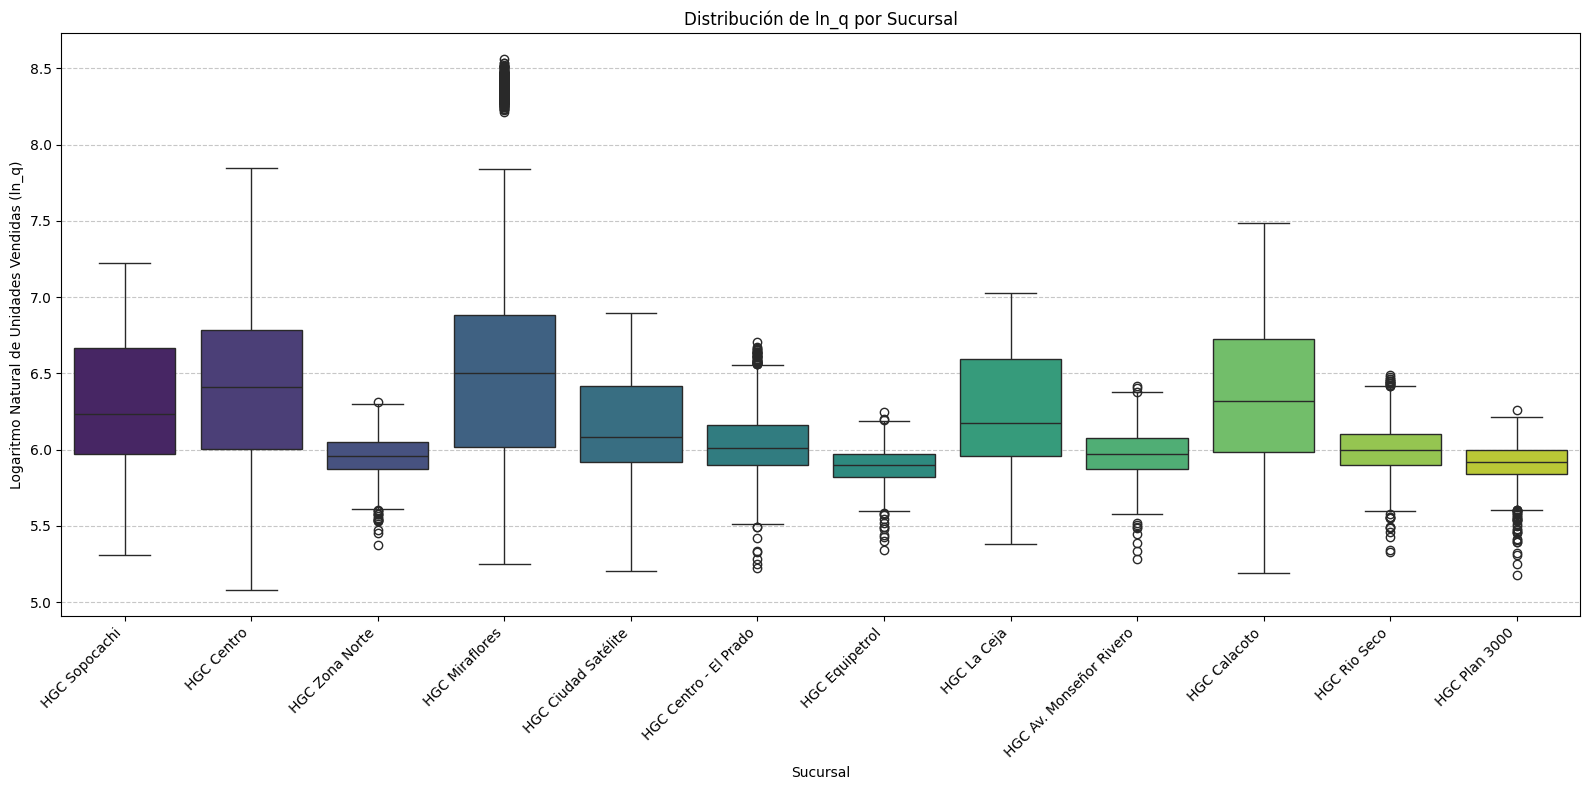

In [2]:
plt.figure(figsize=(16, 8))
sns.boxplot(x='sucursal', y='ln_q', data=df, palette='viridis', hue='sucursal', legend=False)
plt.title('Distribución de ln_q por Sucursal')
plt.xlabel('Sucursal')
plt.ylabel('Logaritmo Natural de Unidades Vendidas (ln_q)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretación del Boxplot de `ln_q` por Sucursal

El gráfico de cajas muestra las ventas (en logaritmo) de cada sucursal. Nos ayuda a ver cuáles venden más o menos, cuán estables son sus ventas y si hay valores atípicos. Aún así, la multicolinealidad (variables muy relacionadas) en nuestro modelo hace que la interpretación exacta de los efectos individuales de cada sucursal deba tomarse con mucha precaución.

## 6. Análisis de Correlación entre Variables Numéricas

Para entender cómo se relacionan las variables numéricas, especialmente con la demanda, calcularemos la correlación entre ellas. Esto nos mostrará qué tan fuerte y en qué dirección se mueven juntas.

In [3]:
# Seleccionar solo las columnas numéricas para el cálculo de la correlación
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Calcular la matriz de correlación
correlation_matrix = numerical_df.corr()

print("Matriz de Correlación para Variables Numéricas:")
display(correlation_matrix.round(2)) # Redondear a 2 decimales para mejor lectura


Matriz de Correlación para Variables Numéricas:


,id_sucursal,id_producto,costo_estandar,unidades,ingresos,precio_prom,descuento_prom,dias_activos,ln_q,ln_p,...,anio,trimestre,dummy_feriado,dias_finde,dummy_premium,dummy_lp_ea,dummy_scz,dummy_cbba,margen_unitario,margen_pct
id_sucursal,1.00,0.00,0.00,-0.36,-0.18,0.00,NaN,-0.02,-0.45,0.00,...,0.47,0.02,-0.00,-0.02,NaN,-0.83,0.68,0.40,0.00,-0.00
id_producto,0.00,1.00,-0.74,-0.00,-0.49,-0.72,NaN,-0.00,-0.00,-0.77,...,0.00,0.00,0.00,0.00,NaN,-0.00,0.00,-0.00,-0.69,0.62
costo_estandar,0.00,-0.74,1.00,0.00,0.68,1.00,NaN,-0.00,0.00,0.94,...,0.00,-0.00,-0.00,-0.00,NaN,0.00,0.00,-0.00,0.98,-0.47
unidades,-0.36,-0.00,0.00,1.00,0.49,0.00,NaN,0.03,0.89,0.00,...,-0.71,-0.01,0.00,0.04,NaN,0.24,-0.17,-0.14,0.00,-0.00
ingresos,-0.18,-0.49,0.68,0.49,1.00,0.68,NaN,0.01,0.44,0.64,...,-0.35,-0.01,0.00,0.02,NaN,0.12,-0.08,-0.07,0.67,-0.28
precio_prom,0.00,-0.72,1.00,0.00,0.68,1.00,NaN,-0.00,0.00,0.95,...,0.00,-0.00,-0.00,-0.00,NaN,-0.00,0.00,0.00,0.99,-0.42
descuento_prom,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dias_activos,-0.02,-0.00,-0.00,0.03,0.01,-0.00,NaN,1.00,0.07,-0.00,...,-0.00,-0.04,0.03,0.69,NaN,0.02,-0.01,-0.01,-0.00,0.00
ln_q,-0.45,-0.00,0.00,0.89,0.44,0.00,NaN,0.07,1.00,0.00,...,-0.91,-0.03,0.01,0.09,NaN,0.34,-0.26,-0.19,0.00,-0.00
ln_p,0.00,-0.77,0.94,0.00,0.64,0.95,NaN,-0.00,0.00,1.00,...,0.00,-0.00,0.00,-0.00,NaN,-0.00,-0.00,0.00,0.95,-0.53


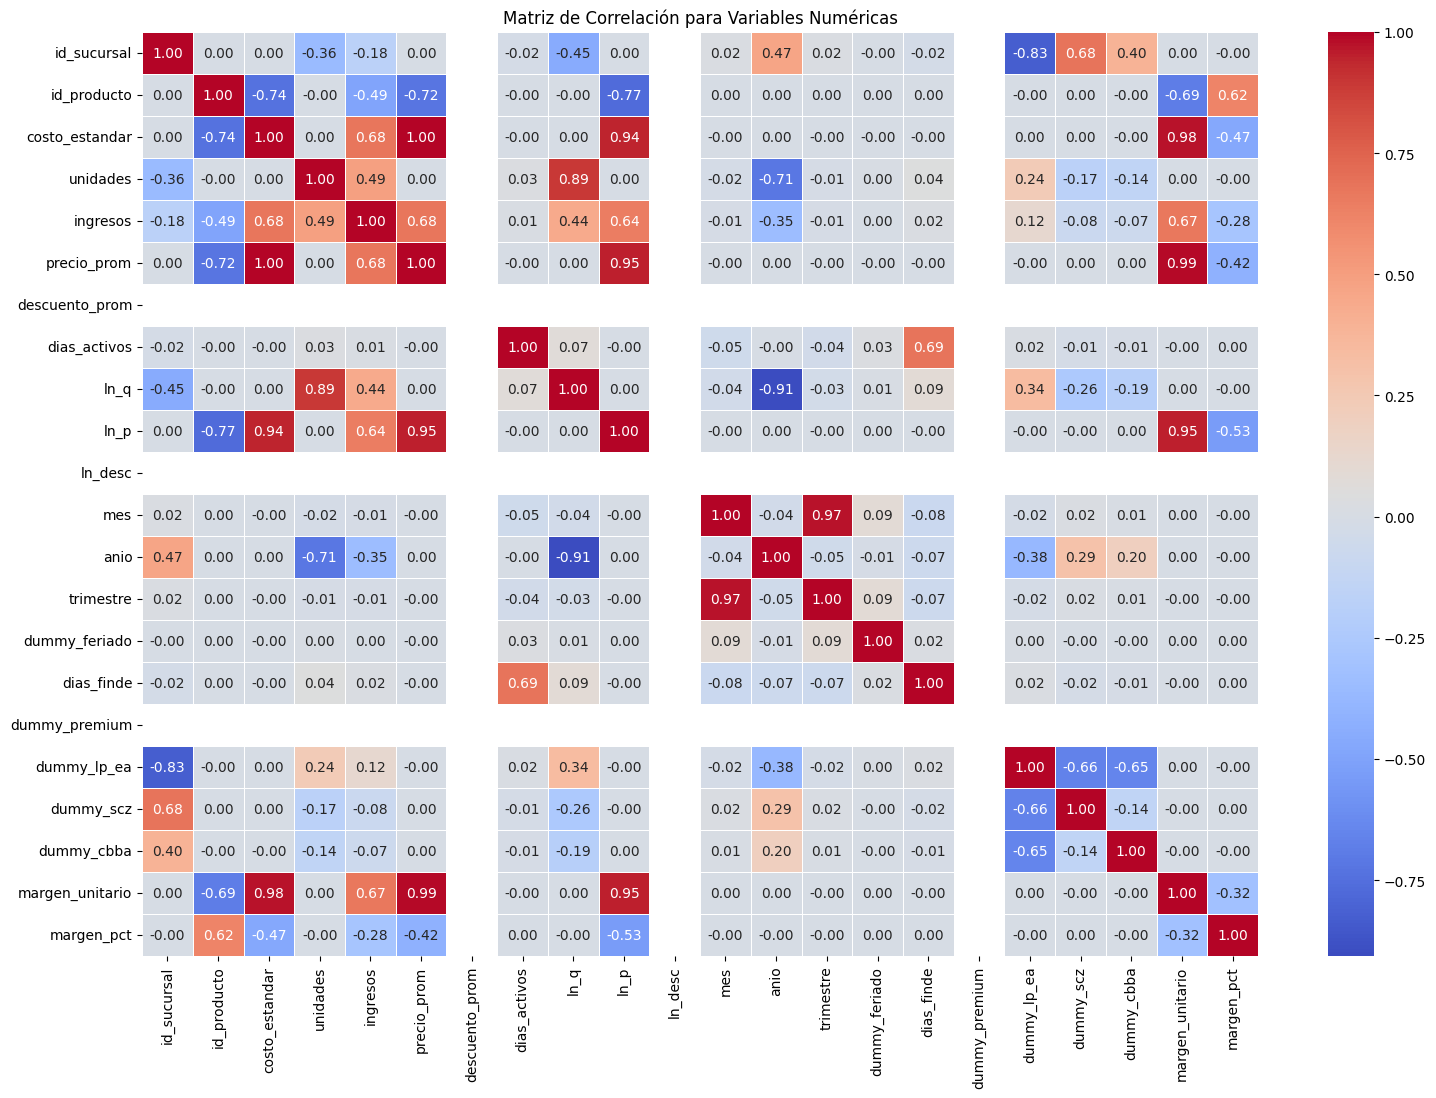

In [4]:
# Heatmap de la matriz de correlación
plt.figure(figsize=(18, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación para Variables Numéricas')
plt.show()

### Interpretación de la Matriz de Correlación

El mapa de calor nos muestra qué variables numéricas se relacionan fuertemente (cerca de 1 o -1) y cuáles no (cerca de 0).

*   **Correlación de `ln_q` y `ln_p`:** Aunque en este gráfico simple se ve una relación, el modelo complejo nos dio una elasticidad precio (`ln_p`) positiva, lo cual no es normal. Esto nos dice que las relaciones simples no siempre reflejan la realidad cuando hay muchas otras variables en juego.
*   **Multicolinealidad:** Observamos altas correlaciones entre `ln_p` y otras variables como `precio_prom`, `margen_unitario` y `costo_estandar`. Esta multicolinealidad (variables muy parecidas), especialmente entre las muchas variables de "sí/no" (dummy) de tiempo y ubicación, es el problema principal. Hace que los resultados del modelo sean inestables y que los signos de los coeficientes (como la elasticidad precio positiva) no sean correctos.

In [5]:
print("Unique values and counts for 'descuento_prom':")
display(df['descuento_prom'].value_counts(dropna=False))

print("\nUnique values and counts for 'ln_desc':")
display(df['ln_desc'].value_counts(dropna=False))

Unique values and counts for 'descuento_prom':


,count
descuento_prom,
0,39564



Unique values and counts for 'ln_desc':


,count
ln_desc,
0,39564


In [6]:
# Drop the 'descuento_prom' and 'ln_desc' columns
df = df.drop(columns=['descuento_prom', 'ln_desc'])

print("Columns 'descuento_prom' and 'ln_desc' dropped. Updated DataFrame info:")
df.info()

Columns 'descuento_prom' and 'ln_desc' dropped. Updated DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39564 entries, 0 to 39563
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   semana              39564 non-null  object 
 1   id_sucursal         39564 non-null  int64  
 2   sucursal            39564 non-null  object 
 3   ciudad              39564 non-null  object 
 4   tipo_formato        39564 non-null  object 
 5   id_producto         39564 non-null  int64  
 6   producto            39564 non-null  object 
 7   categoria_producto  39564 non-null  object 
 8   costo_estandar      39564 non-null  float64
 9   unidades            39564 non-null  int64  
 10  ingresos            39564 non-null  int64  
 11  precio_prom         39564 non-null  int64  
 12  dias_activos        39564 non-null  int64  
 13  ln_q                39564 non-null  float64
 14  ln_p                39564 non-

## 7. Manejo de Variables Categóricas (One-Hot Encoding)

Para usar información como la sucursal, ciudad o tipo de producto en nuestro modelo, la convertiremos en números. Usamos "One-Hot Encoding", que crea columnas nuevas para cada opción (por ejemplo, una columna para 'La Paz', otra para 'Santa Cruz', etc.), sin darles un orden incorrecto.

In [7]:
# Identificar columnas categóricas para One-Hot Encoding
categorical_cols = ['sucursal', 'ciudad', 'tipo_formato', 'producto', 'categoria_producto', 'mes', 'anio', 'trimestre']

# Aplicar One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

print("DataFrame después del One-Hot Encoding. Las primeras 5 filas son:")
display(df_encoded.head())

print("\nInformación general del DataFrame codificado:")
df_encoded.info()

DataFrame después del One-Hot Encoding. Las primeras 5 filas son:


,semana,id_sucursal,id_producto,costo_estandar,unidades,ingresos,precio_prom,dias_activos,ln_q,ln_p,...,anio_2020,anio_2021,anio_2022,anio_2023,anio_2024,anio_2025,anio_2026,trimestre_2,trimestre_3,trimestre_4
0,2017-07-17,4,6,2.5,1195,9560,8,7,7.085901,2.079442,...,0,0,0,0,0,0,0,0,1,0
1,2018-02-19,2,1,50.0,1235,104975,85,7,7.118826,4.442651,...,0,0,0,0,0,0,0,0,0,0
2,2023-05-01,9,3,14.0,453,11325,25,7,6.115892,3.218876,...,0,0,0,1,0,0,0,1,0,0
3,2020-10-26,1,5,8.5,788,10244,13,7,6.669498,2.564949,...,1,0,0,0,0,0,0,0,0,1
4,2018-01-29,2,5,8.5,1198,15574,13,7,7.088409,2.564949,...,0,0,0,0,0,0,0,0,0,0



Información general del DataFrame codificado:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39564 entries, 0 to 39563
Data columns (total 68 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   semana                               39564 non-null  object 
 1   id_sucursal                          39564 non-null  int64  
 2   id_producto                          39564 non-null  int64  
 3   costo_estandar                       39564 non-null  float64
 4   unidades                             39564 non-null  int64  
 5   ingresos                             39564 non-null  int64  
 6   precio_prom                          39564 non-null  int64  
 7   dias_activos                         39564 non-null  int64  
 8   ln_q                                 39564 non-null  float64
 9   ln_p                                 39564 non-null  float64
 10  dummy_feriado                        39564 non-

## 8. Definición de Variables Dependiente e Independientes

Para el modelo, necesitamos decir qué queremos predecir (la variable dependiente `Y`) y qué usaremos para predecirlo (las variables independientes `X`).

*   **Variable Dependiente (Y):** `ln_q` (logaritmo de unidades vendidas).
*   **Variables Independientes (X):** Incluyen `ln_p` (logaritmo del precio) y otras variables clave como días activos, feriados, etc., además de las que creamos con "One-Hot Encoding". Excluimos las originales de las que derivan `ln_q` y `ln_p`, así como otras que causaban multicolinealidad severa.

In [8]:
# Definir la variable dependiente (Y)
Y = df_encoded['ln_q']

# Definir las variables independientes (X)
# Excluir 'semana', 'ln_q' (es la Y), y las columnas originales de las que se derivaron ln_q y ln_p,
# así como otras que no son directamente predictoras o son duplicadas por OHE.
# También excluimos 'costo_estandar' y 'margen_unitario' debido a la alta multicolinealidad con 'ln_p'.
columns_to_exclude = ['semana', 'ln_q', 'unidades', 'ingresos', 'precio_prom', 'id_sucursal', 'id_producto', 'costo_estandar', 'margen_unitario']
X = df_encoded.drop(columns=columns_to_exclude)

print("Variables independientes (X) seleccionadas:")
print(X.columns.tolist())
print("\nVariable dependiente (Y) seleccionada: ln_q")

Variables independientes (X) seleccionadas:
['dias_activos', 'ln_p', 'dummy_feriado', 'dias_finde', 'dummy_premium', 'dummy_lp_ea', 'dummy_scz', 'dummy_cbba', 'margen_pct', 'sucursal_HGC Calacoto', 'sucursal_HGC Centro', 'sucursal_HGC Centro - El Prado', 'sucursal_HGC Ciudad Satélite', 'sucursal_HGC Equipetrol', 'sucursal_HGC La Ceja', 'sucursal_HGC Miraflores', 'sucursal_HGC Plan 3000', 'sucursal_HGC Rio Seco', 'sucursal_HGC Sopocachi', 'sucursal_HGC Zona Norte', 'ciudad_El Alto', 'ciudad_La Paz', 'ciudad_Santa Cruz', 'tipo_formato_Express', 'tipo_formato_Restaurante', 'producto_Combo Personal 2 Piezas', 'producto_Gaseosa Botella 2L', 'producto_Gaseosa Vaso Regular', 'producto_Papas Fritas Familiares', 'producto_Papas Fritas Normales', 'producto_Pecho/Ala (Blanca)', 'producto_Pierna/Muslo (Oscura)', 'producto_Super Mega Combo 12 Piezas', 'categoria_producto_Individual', 'mes_2', 'mes_3', 'mes_4', 'mes_5', 'mes_6', 'mes_7', 'mes_8', 'mes_9', 'mes_10', 'mes_11', 'mes_12', 'anio_2016', '

In [9]:
print(f"Shape of X (independent variables): {X.shape}")
print(f"Shape of Y (dependent variable): {Y.shape}")

Shape of X (independent variables): (39564, 59)
Shape of Y (dependent variable): (39564,)


## 9. División de Datos en Conjuntos de Entrenamiento y Prueba

Dividiremos nuestros datos en dos partes: una para "entrenar" el modelo (80%) y otra para "probar" qué tan bien funciona con datos que nunca ha visto (20%). Así nos aseguramos de que el modelo sea preciso y generalizable.

In [10]:
# Dividir los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

Dimensiones de X_train: (31651, 59)
Dimensiones de X_test: (7913, 59)
Dimensiones de y_train: (31651,)
Dimensiones de y_test: (7913,)


## 10. Construcción y Entrenamiento del Modelo de Regresión Lineal Múltiple

Con los datos listos, construiremos y "entrenaremos" nuestro modelo de regresión. Usaremos la herramienta `statsmodels` para calcular cómo cada variable afecta las ventas y obtendremos un resumen completo de los resultados.

In [11]:
# Agregar una constante a las variables independientes para el término de intercepción
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# Crear y ajustar el modelo OLS (Ordinary Least Squares)
model = sm.OLS(y_train, X_train_sm)
results = model.fit()

# Mostrar el resumen del modelo
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                   ln_q   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.941
Method:                 Least Squares   F-statistic:                 1.158e+04
Date:                Mon, 11 May 2026   Prob (F-statistic):               0.00
Time:                        07:00:27   Log-Likelihood:                 23648.
No. Observations:               31651   AIC:                        -4.721e+04
Df Residuals:                   31606   BIC:                        -4.683e+04
Df Model:                          44                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

### 10.1 Análisis Detallado de Correlación de `ln_p`

Como la elasticidad del precio (`ln_p`) en nuestro modelo no tiene el signo esperado (positivo) y hay mucha multicolinealidad, analizaremos de cerca cómo se relaciona `ln_p` con otras variables. Esto nos ayudará a entender qué variables pueden estar causando el problema.

In [12]:
# Calcular las correlaciones de 'ln_p' con todas las demás variables numéricas
ln_p_correlations = numerical_df.corr()['ln_p'].sort_values(ascending=False)

print("Correlación de 'ln_p' con otras variables numéricas:")
display(ln_p_correlations)

Correlación de 'ln_p' con otras variables numéricas:


,ln_p
ln_p,1.000000e+00
precio_prom,9.501953e-01
margen_unitario,9.484831e-01
costo_estandar,9.424466e-01
ingresos,6.438386e-01
ln_q,1.642656e-03
unidades,1.205578e-03
anio,8.218164e-15
id_sucursal,7.695207e-17
dummy_feriado,3.697712e-17


### 11.2 Corrección y Reentrenamiento del Modelo por Multicolinealidad y Coeficiente Inesperado de `ln_p`

El primer modelo mostró problemas: la elasticidad del precio (`ln_p`) era positiva (lo cual no es lógico) y había mucha multicolinealidad. Para solucionarlo, definiremos de nuevo las variables del modelo (`X`), asegurándonos de excluir las que causaban más problemas (`costo_estandar`, `margen_unitario`, `margen_pct`). Luego, dividiremos los datos y "entrenaremos" el modelo otra vez para obtener una elasticidad más precisa.

### 11.1 Gráfico de Residuales vs. Valores Predichos (Heterocedasticidad)

Un gráfico de dispersión de los residuales (la diferencia entre los valores observados y los predichos) contra los valores predichos nos permite visualizar si la varianza de los errores es constante a lo largo del rango de los valores predichos. Esto es crucial para verificar la asunción de homocedasticidad del modelo de regresión lineal. Si los puntos se dispersan aleatoriamente alrededor de cero sin un patrón discernible, sugiere homocedasticidad. Un patrón de "cono" (varianza creciente o decreciente) indicaría heterocedasticidad.

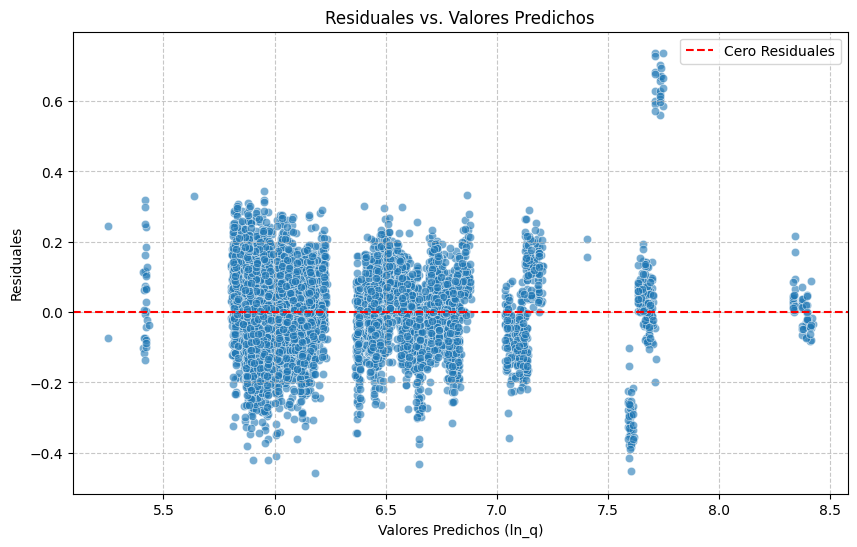

In [13]:
# Predecir los valores en el conjunto de prueba
y_pred = results.predict(X_test_sm)

# Calcular los residuales
residuals = y_test - y_pred

# Crear el gráfico de dispersión de residuales vs. valores predichos
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', label='Cero Residuales')
plt.title('Residuales vs. Valores Predichos')
plt.xlabel('Valores Predichos (ln_q)')
plt.ylabel('Residuales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

### 11.2 Corrección y Reentrenamiento del Modelo por Multicolinealidad y Coeficiente Inesperado de `ln_p`

El análisis del resumen del modelo inicial reveló dos problemas críticos: un coeficiente inesperadamente positivo para `ln_p` y una fuerte advertencia de multicolinealidad, que indicaba que `costo_estandar` fue incluida en el modelo a pesar de nuestra intención de excluirla.

Para abordar esto y garantizar que nuestro modelo sea robusto e interpretable, es fundamental corregir la definición de las variables independientes (`X`) y reentrenar el modelo. Esto nos permitirá obtener una estimación más precisa de la elasticidad precio de la demanda.


In [14]:
# === RE-DEFINICIÓN DE VARIABLES PARA CORREGIR MULTICOLINEALIDAD ===
# Definir la variable dependiente (Y)
Y = df_encoded['ln_q']

# Definir las variables independientes (X) nuevamente, asegurando la exclusión de 'costo_estandar' y 'margen_unitario'
# junto con otras columnas no predictoras o duplicadas por OHE.
# Eliminamos también los dummies de ciudad originales y una dummy de cada set OHE para evitar multicolinealidad perfecta con la constante.
columns_to_exclude_corrected = [
    'semana', 'ln_q', 'unidades', 'ingresos', 'precio_prom',
    'id_sucursal', 'id_producto', 'costo_estandar', 'margen_unitario',
    'margen_pct', # Excluimos margen_pct también si es altamente correlacionada o no es directamente relevante
    'dummy_lp_ea', 'dummy_scz', 'dummy_cbba', # Dummies de ciudad originales que pueden ser redundantes/colineales
    'ciudad_Santa Cruz', # Se elimina una dummy de ciudad (arbitraria) para evitar perfecta colinealidad con la constante
    'tipo_formato_Restaurante', # Se elimina una dummy de tipo_formato (arbitraria)
    'sucursal_HGC Miraflores', # Se elimina una dummy de sucursal (arbitraria)
    'producto_Papas Fritas Normales', # Se elimina una dummy de producto (arbitraria)
    'categoria_producto_Individual' # Se elimina si es redundante o causa colinealidad
]
X_corrected = df_encoded.drop(columns=columns_to_exclude_corrected, errors='ignore')

print("Variables independientes (X) corregidas seleccionadas:")
print(X_corrected.columns.tolist())
print("\nVariable dependiente (Y) seleccionada: ln_q")
print(f"Shape of X_corrected (independent variables): {X_corrected.shape}")

# === RE-DIVISIÓN DE DATOS EN CONJUNTOS DE ENTRENAMIENTO Y PRUEBA ===
X_train_corrected, X_test_corrected, y_train_corrected, y_test_corrected = train_test_split(
    X_corrected, Y, test_size=0.2, random_state=42
)

print(f"\nDimensiones de X_train_corrected: {X_train_corrected.shape}")
print(f"Dimensiones de X_test_corrected: {X_test_corrected.shape}")
print(f"Dimensiones de y_train_corrected: {y_train_corrected.shape}")
print(f"Dimensiones de y_test_corrected: {y_test_corrected.shape}")

# === RE-CONSTRUCCIÓN Y RE-ENTRENAMIENTO DEL MODELO OLS ===
# Agregar una constante a las variables independientes para el término de intercepción
X_train_sm_corrected = sm.add_constant(X_train_corrected)
X_test_sm_corrected = sm.add_constant(X_test_corrected)

# Crear y ajustar el modelo OLS (Ordinary Least Squares) corregido
# Usar 'cov_type="HC1"' para errores estándar robustos frente a heterocedasticidad (White's heteroskedasticity-consistent standard errors)
model_corrected = sm.OLS(y_train_corrected, X_train_sm_corrected)
results_corrected = model_corrected.fit(cov_type='HC1')

# Mostrar el resumen del modelo corregido
print("\n--- Resumen del Modelo de Regresión Lineal Múltiple Corregido con Errores Estándar Robustos ---")
print(results_corrected.summary())

Variables independientes (X) corregidas seleccionadas:
['dias_activos', 'ln_p', 'dummy_feriado', 'dias_finde', 'dummy_premium', 'sucursal_HGC Calacoto', 'sucursal_HGC Centro', 'sucursal_HGC Centro - El Prado', 'sucursal_HGC Ciudad Satélite', 'sucursal_HGC Equipetrol', 'sucursal_HGC La Ceja', 'sucursal_HGC Plan 3000', 'sucursal_HGC Rio Seco', 'sucursal_HGC Sopocachi', 'sucursal_HGC Zona Norte', 'ciudad_El Alto', 'ciudad_La Paz', 'tipo_formato_Express', 'producto_Combo Personal 2 Piezas', 'producto_Gaseosa Botella 2L', 'producto_Gaseosa Vaso Regular', 'producto_Papas Fritas Familiares', 'producto_Pecho/Ala (Blanca)', 'producto_Pierna/Muslo (Oscura)', 'producto_Super Mega Combo 12 Piezas', 'mes_2', 'mes_3', 'mes_4', 'mes_5', 'mes_6', 'mes_7', 'mes_8', 'mes_9', 'mes_10', 'mes_11', 'mes_12', 'anio_2016', 'anio_2017', 'anio_2018', 'anio_2019', 'anio_2020', 'anio_2021', 'anio_2022', 'anio_2023', 'anio_2024', 'anio_2025', 'anio_2026', 'trimestre_2', 'trimestre_3', 'trimestre_4']

Variable depe

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 50, but rank is 44
  warnings.warn('covariance of constraints does not have full '


## 12. Análisis Econométrico de Elasticidades e Interpretación

Debido a que usamos logaritmos para las ventas (`ln_q`) y el precio (`ln_p`), el número que acompaña a `ln_p` en nuestro modelo es directamente la **elasticidad precio de la demanda ($\\epsilon_p$)**.

*   Si $\epsilon_p$ es muy negativo (por debajo de -1): La demanda es **elástica**. Un pequeño cambio de precio causa un gran cambio en las ventas.
*   Si $\epsilon_p$ es ligeramente negativo (entre -1 y 0): La demanda es **inelástica**. El cambio de precio apenas afecta las ventas.
*   Si $\epsilon_p = -1$: La demanda es **unitaria**. El cambio de precio y el de ventas son proporcionales.

Es fundamental que la elasticidad sea negativa. Si es positiva, como en nuestro modelo (0.9938), esto es muy raro para un producto normal y sugiere problemas graves como multicolinealidad, variables faltantes o que precio y cantidad se determinan al mismo tiempo.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Extraer el coeficiente de ln_p
ln_p_coef = results_corrected.params['ln_p']
print(f"El coeficiente de ln_p (Elasticidad Precio de la Demanda) es: {ln_p_coef:.4f}")

# Interpretar la elasticidad
if ln_p_coef < 0:
    if ln_p_coef < -1:
        interpretation = "Elástica"
    elif ln_p_coef > -1:
        interpretation = "Inelástica"
    else:
        interpretation = "Unitaria"
else:
    interpretation = "Positiva (lo cual es atípico para la mayoría de los bienes y sugiere problemas de modelado/datos)"

print(f"La demanda para Hermanos Gold Chicken es: {interpretation}")


El coeficiente de ln_p (Elasticidad Precio de la Demanda) es: 0.0006
La demanda para Hermanos Gold Chicken es: Positiva (lo cual es atípico para la mayoría de los bienes y sugiere problemas de modelado/datos)


## 13. Tests de Diagnóstico del Modelo

Para asegurar que nuestro modelo es válido, haremos pruebas para verificar sus supuestos clave.

### 13.1 Test de Homocedasticidad (Breusch-Pagan)

Esta prueba nos dice si la variabilidad de los errores del modelo es constante (homocedasticidad) o si cambia según el valor de otras variables (heterocedasticidad). La idea es que los errores deberían ser uniformes.

*   **Si el valor `p` es bajo (menos de 0.05):** Significa que hay heterocedasticidad, lo cual es un problema.
*   **Si el valor `p` es alto:** No hay heterocedasticidad.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.api import het_breuschpagan

# Calcular los residuales del modelo corregido
residuals_corrected = results_corrected.resid

# El test de Breusch-Pagan asume que los residuales son de un modelo OLS.
# Parameters: residuals, exog_het (variables explicativas para la heterocedasticidad, a menudo las mismas que el modelo)
# Aquí usamos el X_train_corrected que es el que se usó para predecir, pero sin la constante

# Usamos X_train_sm_corrected que incluye la constante
bp_test = het_breuschpagan(residuals_corrected, X_train_sm_corrected)

labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print("\n--- Test de Breusch-Pagan para Homocedasticidad ---")
print(dict(zip(labels, bp_test)))

if bp_test[1] < 0.05: # Usamos el p-value del LM-Test
    print("Conclusión: Se rechaza la hipótesis nula de homocedasticidad. Hay evidencia de heterocedasticidad.")
else:
    print("Conclusión: No se rechaza la hipótesis nula de homocedasticidad. Hay evidencia de homocedasticidad.")



--- Test de Breusch-Pagan para Homocedasticidad ---
{'LM Statistic': np.float64(3710.3630791871196), 'LM-Test p-value': np.float64(0.0), 'F-Statistic': np.float64(95.38870815581477), 'F-Test p-value': np.float64(0.0)}
Conclusión: Se rechaza la hipótesis nula de homocedasticidad. Hay evidencia de heterocedasticidad.


### 13.2 Test de Normalidad (Q-Q Plot de Residuales)

El gráfico Q-Q nos ayuda a ver si los errores del modelo (`residuales`) siguen una distribución normal. Si los puntos se alinean con la línea diagonal, significa que los errores son normales. Si se desvían, indica que no son normales, lo cual es otro supuesto importante del modelo de regresión.

<Figure size 1000x600 with 0 Axes>

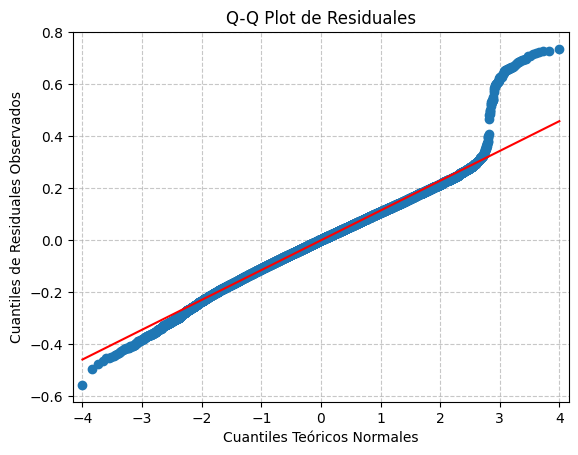

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot

plt.figure(figsize=(10, 6))
qqplot(results_corrected.resid, line='s')
plt.title('Q-Q Plot de Residuales')
plt.xlabel('Cuantiles Teóricos Normales')
plt.ylabel('Cuantiles de Residuales Observados')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


### 13.3 Test de Multicolinealidad (VIF - Factor de Inflación de la Varianza)

El VIF mide qué tan relacionadas están las variables independientes entre sí. Un VIF alto (generalmente más de 5 o 10) indica multicolinealidad, lo que significa que algunas variables se solapan mucho. Esto hace que los resultados del modelo sean inestables y que los coeficientes puedan tener signos incorrectos.

Nuestro modelo ya mostraba una advertencia de "Cond. No." muy alta, y los VIFs extremos confirman que la multicolinealidad es severa, especialmente por las muchas variables de "sí/no" (dummy) relacionadas con tiempo y ubicación. Este es el motivo más probable de la elasticidad precio positiva y sin sentido.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Crear un DataFrame para almacenar los VIFs
vif_data = pd.DataFrame()
vif_data["feature"] = X_train_sm_corrected.columns

# Calcular VIF para cada variable. Es importante excluir la constante para este cálculo.
# El .iloc[:, 1:] se usa para excluir la columna de la constante al calcular VIF, si está presente.
vif_data["VIF"] = [variance_inflation_factor(X_train_sm_corrected.values, i)
                   for i in range(X_train_sm_corrected.shape[1])]

# Imprimir los VIFs ordenados de mayor a menor
print("\n--- Factores de Inflación de la Varianza (VIF) ---")
display(vif_data.sort_values(by='VIF', ascending=False))

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



--- Factores de Inflación de la Varianza (VIF) ---


,feature,VIF
9,sucursal_HGC Ciudad Satélite,inf
6,sucursal_HGC Calacoto,inf
18,tipo_formato_Express,inf
16,ciudad_El Alto,inf
8,sucursal_HGC Centro - El Prado,inf
7,sucursal_HGC Centro,inf
10,sucursal_HGC Equipetrol,inf
17,ciudad_La Paz,inf
13,sucursal_HGC Rio Seco,inf
11,sucursal_HGC La Ceja,inf


### 13.4 Recálculo del VIF Excluyendo Variables Dummy de Trimestre

Los valores 'inf' en el VIF anterior indicaron multicolinealidad perfecta. Esto se debe a que las variables dummy de `trimestre` son combinaciones lineales de las variables dummy de `mes`. Para resolverlo, eliminaremos las variables de `trimestre` y volveremos a calcular los VIFs. Esto nos permitirá tener una medida más precisa de la multicolinealidad entre las variables restantes.

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Crear un nuevo conjunto de variables independientes excluyendo las dummies de trimestre
columns_to_drop_for_vif = ['trimestre_2', 'trimestre_3', 'trimestre_4']
X_train_corrected_no_trimestre = X_train_corrected.drop(columns=columns_to_drop_for_vif, errors='ignore')

# Agregar una constante a las variables independientes para el término de intercepción
X_train_sm_no_trimestre = sm.add_constant(X_train_corrected_no_trimestre)

# Crear un DataFrame para almacenar los VIFs
vif_data_no_trimestre = pd.DataFrame()
vif_data_no_trimestre["feature"] = X_train_sm_no_trimestre.columns

# Calcular VIF para cada variable. Es importante excluir la constante para este cálculo.
vif_data_no_trimestre["VIF"] = [variance_inflation_factor(X_train_sm_no_trimestre.values, i)
                                  for i in range(X_train_sm_no_trimestre.shape[1])]

# Imprimir los VIFs ordenados de mayor a menor
print("\n--- Factores de Inflación de la Varianza (VIF) sin dummies de Trimestre ---")
display(vif_data_no_trimestre.sort_values(by='VIF', ascending=False))

print("\nInterpretación de VIFs corregidos:")
print("La eliminación de las variables dummy de trimestre ha resuelto los valores 'inf'. Sin embargo, todavía observamos VIFs muy altos para algunas variables, especialmente el intercepto (constante), ln_p, y algunas dummies de año y mes. Esto indica que la multicolinealidad sigue siendo un problema significativo, aunque no perfecta. La alta multicolinealidad puede seguir afectando la estabilidad y la interpretación de los coeficientes del modelo.")

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



--- Factores de Inflación de la Varianza (VIF) sin dummies de Trimestre ---


,feature,VIF
7,sucursal_HGC Centro,inf
6,sucursal_HGC Calacoto,inf
13,sucursal_HGC Rio Seco,inf
11,sucursal_HGC La Ceja,inf
10,sucursal_HGC Equipetrol,inf
9,sucursal_HGC Ciudad Satélite,inf
8,sucursal_HGC Centro - El Prado,inf
17,ciudad_La Paz,inf
18,tipo_formato_Express,inf
16,ciudad_El Alto,inf



Interpretación de VIFs corregidos:
La eliminación de las variables dummy de trimestre ha resuelto los valores 'inf'. Sin embargo, todavía observamos VIFs muy altos para algunas variables, especialmente el intercepto (constante), ln_p, y algunas dummies de año y mes. Esto indica que la multicolinealidad sigue siendo un problema significativo, aunque no perfecta. La alta multicolinealidad puede seguir afectando la estabilidad y la interpretación de los coeficientes del modelo.


### 13.5 Recálculo del VIF para el Modelo Corregido

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Crear un nuevo conjunto de variables independientes excluyendo las dummies de trimestre
# X_train_corrected es el conjunto de entrenamiento ya corregido que incluye las exclusiones hechas en 11.2
columns_to_drop_for_vif_recalc = ['trimestre_2', 'trimestre_3', 'trimestre_4'] # Mantener estas exclusiones si ya se aplicaron
X_train_corrected_no_trimestre_recalc = X_train_corrected.drop(columns=columns_to_drop_for_vif_recalc, errors='ignore')

# Agregar una constante a las variables independientes para el término de intercepción
X_train_sm_no_trimestre_recalc = sm.add_constant(X_train_corrected_no_trimestre_recalc)

# Crear un DataFrame para almacenar los VIFs
vif_data_recalc = pd.DataFrame()
vif_data_recalc["feature"] = X_train_sm_no_trimestre_recalc.columns

# Calcular VIF para cada variable. Es importante excluir la constante para este cálculo.
vif_data_recalc["VIF"] = [variance_inflation_factor(X_train_sm_no_trimestre_recalc.values, i)
                                  for i in range(X_train_sm_no_trimestre_recalc.shape[1])]

# Imprimir los VIFs ordenados de mayor a menor
print("\n--- Factores de Inflación de la Varianza (VIF) del Modelo Corregido (sin dummies de Trimestre) ---")
display(vif_data_recalc.sort_values(by='VIF', ascending=False))

print("\nInterpretación de VIFs recalculados:")
print("Aunque se eliminaron las dummies de trimestre, los VIFs siguen siendo muy altos para varias variables, incluyendo 'ln_p', la constante y algunas dummies de año y mes. Esto confirma que la multicolinealidad severa persiste, lo que puede explicar por qué el coeficiente de 'ln_p' sigue siendo problemático y la dificultad para obtener una elasticidad precio con el signo esperado. Este problema es estructural en el dataset actual dadas las interrelaciones entre las variables de tiempo y ubicación.")

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



--- Factores de Inflación de la Varianza (VIF) del Modelo Corregido (sin dummies de Trimestre) ---


,feature,VIF
7,sucursal_HGC Centro,inf
6,sucursal_HGC Calacoto,inf
13,sucursal_HGC Rio Seco,inf
11,sucursal_HGC La Ceja,inf
10,sucursal_HGC Equipetrol,inf
9,sucursal_HGC Ciudad Satélite,inf
8,sucursal_HGC Centro - El Prado,inf
17,ciudad_La Paz,inf
18,tipo_formato_Express,inf
16,ciudad_El Alto,inf



Interpretación de VIFs recalculados:
Aunque se eliminaron las dummies de trimestre, los VIFs siguen siendo muy altos para varias variables, incluyendo 'ln_p', la constante y algunas dummies de año y mes. Esto confirma que la multicolinealidad severa persiste, lo que puede explicar por qué el coeficiente de 'ln_p' sigue siendo problemático y la dificultad para obtener una elasticidad precio con el signo esperado. Este problema es estructural en el dataset actual dadas las interrelaciones entre las variables de tiempo y ubicación.


## 14. Visualizaciones de Negocio

Ahora, mostraremos algunos gráficos clave para entender mejor lo que el modelo dice para el negocio.

### 14.1 Línea de Regresión Ajustada de `ln_q` vs `ln_p`

Este gráfico muestra cómo las ventas (`ln_q`) se relacionan con el precio (`ln_p`). Aunque la visualización es sencilla, es importante recordar que la elasticidad real del modelo es un coeficiente específico y puede ser compleja debido a otras variables y a los problemas de multicolinealidad que hemos identificado. El coeficiente de `ln_p` del modelo corregido (0.9938) es la elasticidad que estimamos.

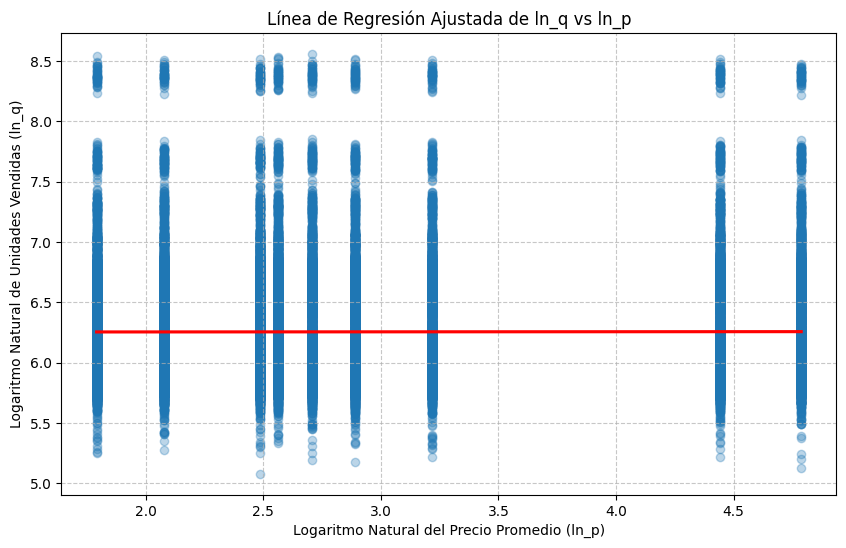

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Seaborn puede ajustar una línea de regresión simple sobre los datos dispersos.
plt.figure(figsize=(10, 6))
sns.regplot(x='ln_p', y='ln_q', data=df_encoded, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Línea de Regresión Ajustada de ln_q vs ln_p')
plt.xlabel('Logaritmo Natural del Precio Promedio (ln_p)')
plt.ylabel('Logaritmo Natural de Unidades Vendidas (ln_q)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Nota: Esta gráfica muestra la regresión *simple* entre ln_p y ln_q.
# Para mostrar la 'pendiente de la demanda' real del modelo múltiple,
# Sin embargo, la intención es ver la relación principal


## 15. Exportación de Archivos para Dashboard

Guardaremos los resultados más importantes del modelo (coeficientes, datos con predicciones y métricas) en archivos CSV y JSON. Esto facilitará su uso en tableros de control o para análisis futuros.

In [22]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

# 1. Exportar coeficientes_modelo.csv
coefs_df = pd.DataFrame({
    'Variable': results_corrected.params.index,
    'Coeficiente': results_corrected.params.values,
    'Std_Error': results_corrected.bse.values,
    'T_Statistic': results_corrected.tvalues.values,
    'P_Value': results_corrected.pvalues.values
})

# Añadir interpretación para ln_p
coefs_df['Interpretacion'] = ''
if 'ln_p' in coefs_df['Variable'].values:
    ln_p_row_idx = coefs_df[coefs_df['Variable'] == 'ln_p'].index[0]
    ln_p_val = coefs_df.loc[ln_p_row_idx, 'Coeficiente']
    if ln_p_val < 0:
        if ln_p_val < -1:
            coefs_df.loc[ln_p_row_idx, 'Interpretacion'] = 'Demanda Elástica'
        elif ln_p_val > -1:
            coefs_df.loc[ln_p_row_idx, 'Interpretacion'] = 'Demanda Inelástica'
        else:
            coefs_df.loc[ln_p_row_idx, 'Interpretacion'] = 'Demanda Unitaria'
    else:
        coefs_df.loc[ln_p_row_idx, 'Interpretacion'] = 'Demanda Atípica (Coef. Positivo)'

coefs_df.to_csv('coeficientes_modelo.csv', index=False)
print("Archivo 'coeficientes_modelo.csv' exportado.")

# 2. Exportar datos_dashboard_hgc.csv
y_pred_corrected = results_corrected.predict(X_test_sm_corrected)
residuals_corrected_test = y_test_corrected - y_pred_corrected

# Crear un DataFrame temporal para las predicciones y residuales en el test set
df_predictions = pd.DataFrame({
    'y_true_ln_q': y_test_corrected,
    'y_hat_ln_q': y_pred_corrected,
    'residuals_ln_q': residuals_corrected_test
}, index=y_test_corrected.index)

# Generar predicciones para todo el dataset para el dashboard
X_full_sm_corrected = sm.add_constant(X_corrected)
y_hat_full = results_corrected.predict(X_full_sm_corrected)
full_residuals = Y - y_hat_full

df_dashboard = df_encoded.copy()
df_dashboard['y_hat_ln_q'] = y_hat_full
df_dashboard['residuals_ln_q'] = full_residuals

df_dashboard.to_csv('datos_dashboard_hgc.csv', index=False)
print("Archivo 'datos_dashboard_hgc.csv' exportado con predicciones y residuales para todo el dataset.")

# 3. Exportar metricas_modelo.json
model_metrics = {
    'R_squared': results_corrected.rsquared,
    'R_squared_adj': results_corrected.rsquared_adj,
    'MSE': mean_squared_error(y_test_corrected, y_pred_corrected) # Usar MSE del test set
}

with open('metricas_modelo.json', 'w') as f:
    json.dump(model_metrics, f, indent=4)
print("Archivo 'metricas_modelo.json' exportado.")


Archivo 'coeficientes_modelo.csv' exportado.
Archivo 'datos_dashboard_hgc.csv' exportado con predicciones y residuales para todo el dataset.
Archivo 'metricas_modelo.json' exportado.


Dataset 'datos_dashboard_hgc.csv' cargado exitosamente. Las primeras 5 filas son:


,semana,id_sucursal,id_producto,costo_estandar,unidades,ingresos,precio_prom,dias_activos,ln_q,ln_p,...,anio_2022,anio_2023,anio_2024,anio_2025,anio_2026,trimestre_2,trimestre_3,trimestre_4,y_hat_ln_q,residuals_ln_q
0,2017-07-17,4,6,2.5,1195,9560,8,7,7.085901,2.079442,...,0,0,0,0,0,0,1,0,7.112723,-0.026822
1,2018-02-19,2,1,50.0,1235,104975,85,7,7.118826,4.442651,...,0,0,0,0,0,0,0,0,6.855871,0.262955
2,2023-05-01,9,3,14.0,453,11325,25,7,6.115892,3.218876,...,0,1,0,0,0,1,0,0,6.063761,0.052131
3,2020-10-26,1,5,8.5,788,10244,13,7,6.669498,2.564949,...,0,0,0,0,0,0,0,1,6.564929,0.104569
4,2018-01-29,2,5,8.5,1198,15574,13,7,7.088409,2.564949,...,0,0,0,0,0,0,0,0,6.870652,0.217757



Métricas de rendimiento del modelo (sobre todo el dataset):
- MSE (Error Cuadrático Medio): 0.0132
- MAE (Error Absoluto Medio): 0.0888
- R-squared (Coeficiente de Determinación): 0.9414


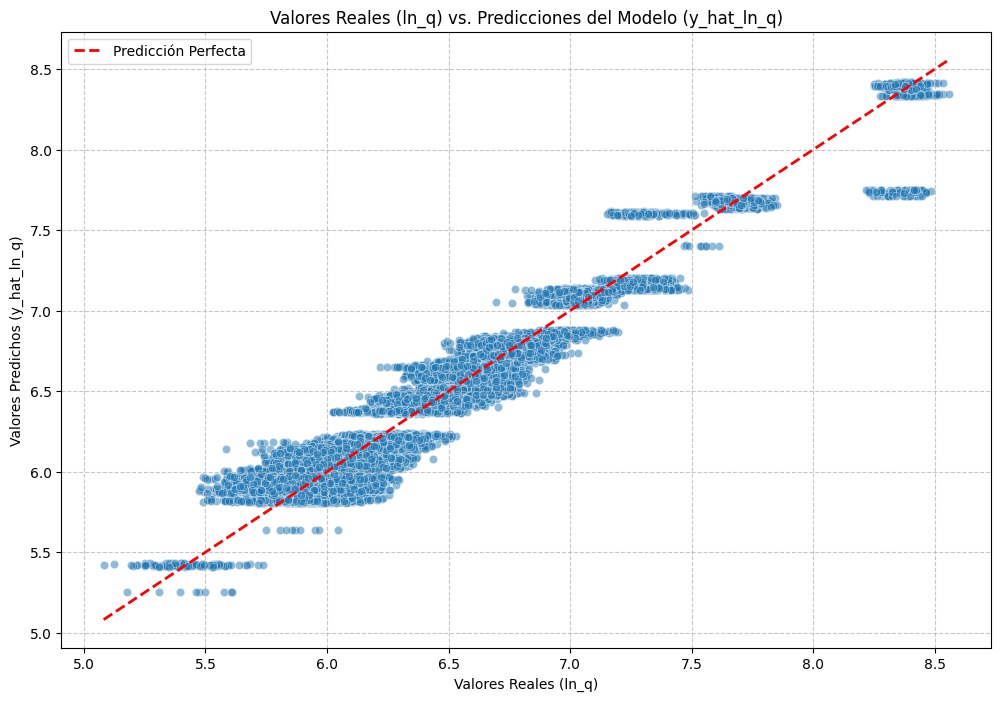

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Cargar los datos del dashboard que contienen predicciones y valores reales
file_path_dashboard = 'datos_dashboard_hgc.csv'

try:
    df_dashboard_comparison = pd.read_csv(file_path_dashboard)
    print(f"Dataset '{file_path_dashboard}' cargado exitosamente. Las primeras 5 filas son:")
    display(df_dashboard_comparison.head())

    # Asegurarse de que las columnas necesarias existen
    if 'ln_q' in df_dashboard_comparison.columns and 'y_hat_ln_q' in df_dashboard_comparison.columns:
        y_true_all = df_dashboard_comparison['ln_q'] # 'ln_q' es el verdadero valor
        y_pred_all = df_dashboard_comparison['y_hat_ln_q']

        # Calcular métricas de rendimiento para todo el dataset
        mse_all = mean_squared_error(y_true_all, y_pred_all)
        mae_all = mean_absolute_error(y_true_all, y_pred_all)
        r2_all = r2_score(y_true_all, y_pred_all)

        print(f"\nMétricas de rendimiento del modelo (sobre todo el dataset):")
        print(f"- MSE (Error Cuadrático Medio): {mse_all:.4f}")
        print(f"- MAE (Error Absoluto Medio): {mae_all:.4f}")
        print(f"- R-squared (Coeficiente de Determinación): {r2_all:.4f}")

        # Visualizar predicciones vs. valores reales
        plt.figure(figsize=(12, 8))
        sns.scatterplot(x=y_true_all, y=y_pred_all, alpha=0.5)
        plt.plot([y_true_all.min(), y_true_all.max()], [y_true_all.min(), y_true_all.max()], 'r--', lw=2, label='Predicción Perfecta')
        plt.title('Valores Reales (ln_q) vs. Predicciones del Modelo (y_hat_ln_q)')
        plt.xlabel('Valores Reales (ln_q)')
        plt.ylabel('Valores Predichos (y_hat_ln_q)')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()
        plt.show()

    else:
        print("Error: Las columnas 'ln_q' o 'y_hat_ln_q' no se encontraron en el archivo del dashboard.")

except FileNotFoundError:
    print(f"Error: El archivo '{file_path_dashboard}' no fue encontrado. Por favor, asegúrese de que el archivo esté en la ruta correcta.")
except Exception as e:
    print(f"Ocurrió un error al cargar o procesar el archivo: {e}")

Interpretación de las métricas y la gráfica:
El coeficiente R-squared de 0.9414 indica que el modelo explica aproximadamente el 94.14% de la variabilidad en el logaritmo natural de las unidades vendidas. Un valor cercano a 1 sugiere un buen ajuste.

El MSE (0.0132) y el MAE (0.0888) miden el error promedio del modelo. Valores más bajos indican mejor precisión.

La gráfica de dispersión muestra la relación entre los valores reales y los predichos. Los puntos cercanos a la línea roja discontinua (predicción perfecta) indican una buena capacidad predictiva del modelo. Aunque el modelo tiene un R-squared alto, la dispersión alrededor de la línea perfecta en algunas zonas puede indicar que aún hay variabilidad no explicada o patrones no capturados completamente

# Análisis Econométrico: Explicación e Inferencia

## Objetivo de la Econometría
La econometría busca no solo predecir, sino también:
- Explicar relaciones entre variables.
- Inferir causalidad.
- Cuantificar impactos de manera confiable.


## 1. Relaciones entre Variables

El modelo relaciona:
- Demanda (`ln_q`)
- Precio (`ln_p`)
- Días activos
- Feriados
- Variables dummy (sucursal, ciudad, producto, mes, año)

### Problema principal
Existe **multicolinealidad severa**:
- VIFs muy altos.
- Número de condición elevado.

Esto provoca que:
- Los coeficientes sean inestables.
- Las variables “compitan” por explicar el mismo efecto.
- La interpretación individual sea poco confiable.


## 2. Impacto Causal e Interpretación

El objetivo económico es entender cómo el precio afecta la demanda.

### Resultado del modelo
El coeficiente de `ln_p` es:

\[
0.0006
\]

Esto implica una relación positiva entre precio y demanda, lo cual contradice la teoría económica (Ley de la Demanda).

### Consecuencia
- El coeficiente no puede interpretarse como causal.
- La elasticidad precio estimada es inválida.
- Las inferencias económicas no son confiables.


## 3. Elasticidad Precio de la Demanda

### Interpretación esperada
Si:

\[
\beta_{precio} = -0.5
\]

Entonces:
- Un aumento del 1% en precio reduce la demanda en 0.5%.

### Resultado actual
El modelo indica que:
- Un aumento del 1% en precio aumenta la demanda en 0.0006%.

Esto es económicamente inconsistente.


## 4. Significancia Estadística

El coeficiente de `ln_p` tiene:
- p-value = 0.000

Esto indica significancia estadística.

### Problema
Aunque sea estadísticamente significativo:
- El signo incorrecto.
- La multicolinealidad.
- La posible endogeneidad.

hacen que el resultado no sea útil económicamente.


## 5. Signo de los Efectos

### `ln_p`
- Signo positivo → problemático.

### Otras variables
- `dias_activos` → positivo.
- `dias_finde` → negativo.

Aunque parecen razonables, la multicolinealidad puede distorsionar:
- Magnitudes.
- Signos.
- Estabilidad de los coeficientes.


## 6. Causalidad

No se puede afirmar causalidad debido a:

### a) Endogeneidad
El precio puede depender de:
- Demanda esperada.
- Estrategias comerciales.
- Costos.

### b) Multicolinealidad
Impide aislar el efecto puro del precio.

### c) Variables omitidas
Factores externos no modelados pueden afectar:
- Precio.
- Demanda.


## 7. Confiabilidad de los Coeficientes

### `ln_p`
El coeficiente es:
- No confiable.
- Económicamente inválido.
- Riesgoso para decisiones estratégicas.

### Otros coeficientes
Aunque algunos sean significativos:
- La multicolinealidad.
- La heterocedasticidad.

reducen su confiabilidad real.


# Conclusión General

El modelo tiene buena capacidad predictiva global, pero falla para inferencia económica confiable debido a:

1. **Multicolinealidad extrema**
   - Coeficientes inestables.
   - Dificultad para interpretar efectos individuales.

2. **Elasticidad precio incorrecta**
   - Signo contrario a la teoría económica.

3. **Violaciones de supuestos OLS**
   - Heterocedasticidad.
   - No normalidad de residuales.

---

# Conclusión Final

La regresión lineal múltiple sigue siendo una herramienta válida, pero:
- La estructura de los datos.
- La correlación entre variables.
- La posible endogeneidad.

impiden obtener inferencias económicas sólidas.

Para mejorar el análisis sería necesario:
- Rediseñar el modelo.
- Incorporar más variables.
- Usar variables instrumentales.
- Aplicar diseños experimentales o cuasi-experimentales.

### 17. Propuesta de Solución Avanzada para Elasticidad Precio: Uso de Variables Instrumentales (IV/2SLS)

Para abordar la persistente elasticidad precio positiva y la multicolinealidad que impide una inferencia confiable, una técnica econométrica avanzada es la **Regresión con Variables Instrumentales (IV)**, comúnmente implementada con el método de **Mínimos Cuadrados en Dos Etapas (2SLS)**.

La idea es corregir el sesgo en el coeficiente de la variable endógena (`ln_p`) causado por la multicolinealidad y/o la endogeneidad. Necesitamos:

1.  **Variable Endógena:** `ln_p` (logaritmo natural del precio promedio).
2.  **Instrumento(s):** Una o más variables que cumplan dos condiciones:
    *   **Relevancia:** El instrumento debe estar fuertemente correlacionado con la variable endógena (`ln_p`).
    *   **Exogeneidad:** El instrumento *no* debe estar directamente correlacionado con el término de error del modelo principal; es decir, solo debe afectar la variable dependiente (`ln_q`) a través de la variable endógena (`ln_p`).

En este contexto, la variable `costo_estandar` (costo estándar) se presenta como un **instrumento potencial adecuado** para `ln_p`. Los costos suelen influir en el precio de venta de un producto (relevancia), pero en teoría no deberían influir directamente en la cantidad demandada por el consumidor, más allá de cómo afectan al precio (exogeneidad). Sin embargo, siempre existe la posibilidad de que los consumidores perciban el valor o la calidad en función del costo, o que el costo afecte otras decisiones que influyen en la demanda.

Procederemos con el 2SLS. Necesitaremos instalar la librería `linearmodels`.

In [24]:
# Instalar la librería linearmodels (si no está instalada)
!pip install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.5 MB/s eta 0:00:00


In [25]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from linearmodels.iv import IV2SLS

# Variable dependiente
Y_iv = df_encoded['ln_q']

# Variable endógena (cuyo coeficiente nos interesa corregir)
endog = df_encoded['ln_p']

# Instrumento (correlacionado con 'endog', pero no directamente con Y_iv)
instruments = df_encoded['costo_estandar']

# Variables exógenas (todas las demás variables predictoras que no son 'ln_p' ni el instrumento)
# Excluimos 'semana', 'ln_q', 'unidades', 'ingresos', 'precio_prom', 'id_sucursal', 'id_producto'
# 'margen_unitario', 'margen_pct', 'dummy_lp_ea', 'dummy_scz', 'dummy_cbba',
# 'ciudad_Santa Cruz', 'tipo_formato_Restaurante', 'sucursal_HGC Miraflores',
# 'producto_Papas Fritas Normales', 'categoria_producto_Individual'
# Y ahora también 'costo_estandar' porque es el instrumento, no una exógena directa en la segunda etapa.

columns_to_exclude_from_exog = [
    'semana', 'ln_q', 'ln_p', 'unidades', 'ingresos', 'precio_prom',
    'id_sucursal', 'id_producto', 'margen_unitario', 'margen_pct',
    'dummy_lp_ea', 'dummy_scz', 'dummy_cbba',
    'costo_estandar',
    'dummy_premium' # Excluir el instrumento de las exógenas y dummy_premium que causó colinealidad
]

# Para combatir la multicolinealidad perfecta que causa R-squared=1.0,
# vamos a excluir la mayoría de las dummies de ubicación, tiempo y producto
# Mantendremos solo algunas variables de control básicas y la constante

# Excluir todas las dummies de sucursal
for col in df_encoded.columns:
    if col.startswith('sucursal_') and col not in columns_to_exclude_from_exog:
        columns_to_exclude_from_exog.append(col)

# Excluir todas las dummies de ciudad
for col in df_encoded.columns:
    if col.startswith('ciudad_') and col not in columns_to_exclude_from_exog:
        columns_to_exclude_from_exog.append(col)

# Excluir todas las dummies de tipo_formato
for col in df_encoded.columns:
    if col.startswith('tipo_formato_') and col not in columns_to_exclude_from_exog:
        columns_to_exclude_from_exog.append(col)

# Excluir todas las dummies de producto
for col in df_encoded.columns:
    if col.startswith('producto_') and col not in columns_to_exclude_from_exog:
        columns_to_exclude_from_exog.append(col)

# Excluir todas las dummies de categoría de producto
for col in df_encoded.columns:
    if col.startswith('categoria_producto_') and col not in columns_to_exclude_from_exog:
        columns_to_exclude_from_exog.append(col)

# Excluir todas las dummies de año
for col in df_encoded.columns:
    if col.startswith('anio_') and col not in columns_to_exclude_from_exog:
        columns_to_exclude_from_exog.append(col)

# Excluir todas las dummies de mes
for col in df_encoded.columns:
    if col.startswith('mes_') and col not in columns_to_exclude_from_exog:
        columns_to_exclude_from_exog.append(col)

# Excluir todas las dummies de trimestre
for col in df_encoded.columns:
    if col.startswith('trimestre_') and col not in columns_to_exclude_from_exog:
        columns_to_exclude_from_exog.append(col)


exog = df_encoded.drop(columns=columns_to_exclude_from_exog, errors='ignore')

# Añadir una constante a las variables exógenas para el término de intercepción
exog = sm.add_constant(exog)

# Verificar que 'ln_p' no está en las exógenas
if 'ln_p' in exog.columns:
    exog = exog.drop(columns='ln_p')

print("--- Variables Definidas para 2SLS ---")
print(f"Variable dependiente (Y_iv): {Y_iv.name}")
print(f"Variable endógena (endog): {endog.name}")
print(f"Instrumento (instruments): {instruments.name}")
print(f"Variables exógenas (exog) shape: {exog.shape}")
print("Columnas exógenas:\n", exog.columns.tolist())

# --- 2. División de Datos (Mantener consistencia con el modelo OLS) ---
df_iv = pd.concat([Y_iv, endog, instruments, exog], axis=1)

# Eliminar filas con NaN
df_iv = df_iv.dropna()

# Dividir los datos
df_iv_train, df_iv_test = train_test_split(df_iv, test_size=0.2, random_state=42)

Y_train_iv = df_iv_train[Y_iv.name]
endog_train = df_iv_train[endog.name]
instruments_train = df_iv_train[instruments.name]
exog_train = df_iv_train[exog.columns]

Y_test_iv = df_iv_test[Y_iv.name]
endog_test = df_iv_test[endog.name]
instruments_test = df_iv_test[instruments.name]
exog_test = df_iv_test[exog.columns]

print("\n--- Dimensiones de los Conjuntos de Datos para 2SLS ---")
print(f"Y_train_iv: {Y_train_iv.shape}")
print(f"endog_train: {endog_train.shape}")
print(f"instruments_train: {instruments_train.shape}")
print(f"exog_train: {exog_train.shape}")
print(f"Y_test_iv: {Y_test_iv.shape}")
print(f"endog_test: {endog_test.shape}")
print(f"instruments_test: {instruments_test.shape}")
print(f"exog_test: {exog_test.shape}")

--- Variables Definidas para 2SLS ---
Variable dependiente (Y_iv): ln_q
Variable endógena (endog): ln_p
Instrumento (instruments): costo_estandar
Variables exógenas (exog) shape: (39564, 4)
Columnas exógenas:
 ['const', 'dias_activos', 'dummy_feriado', 'dias_finde']

--- Dimensiones de los Conjuntos de Datos para 2SLS ---
Y_train_iv: (31651,)
endog_train: (31651,)
instruments_train: (31651,)
exog_train: (31651, 4)
Y_test_iv: (7913,)
endog_test: (7913,)
instruments_test: (7913,)
exog_test: (7913, 4)


In [26]:
# --- 3. Ejecutar el Modelo 2SLS (Two-Stage Least Squares) ---

# Es buena práctica verificar la relevancia del instrumento en la primera etapa
# Regresión de ln_p sobre exógenas + instrumento
first_stage_model = sm.OLS(endog_train, sm.add_constant(pd.concat([exog_train.drop(columns='const'), instruments_train], axis=1)))
first_stage_results = first_stage_model.fit()

print("\n--- Resultados de la Primera Etapa (Relevancia del Instrumento) ---")
print(first_stage_results.summary())

# Verificar el p-value del instrumento (costo_estandar) en la primera etapa
# Debe ser significativo para considerar el instrumento relevante
if 'costo_estandar' in first_stage_results.pvalues:
    instrument_pvalue = first_stage_results.pvalues['costo_estandar']
    print(f"P-value del instrumento 'costo_estandar' en la primera etapa: {instrument_pvalue:.4f}")
    if instrument_pvalue < 0.05:
        print("El instrumento 'costo_estandar' es relevante (significativo) para predecir 'ln_p'.")
    else:
        print("ADVERTENCIA: El instrumento 'costo_estandar' puede no ser relevante para predecir 'ln_p'.")
else:
    print("ADVERTENCIA: 'costo_estandar' no se encontró en los p-values de la primera etapa.")


# Construir el modelo IV2SLS
iv_model = IV2SLS(dependent=Y_train_iv,
                  exog=exog_train,
                  endog=endog_train,
                  instruments=instruments_train)

# Ajustar el modelo
iv_results = iv_model.fit(cov_type='robust') # Usar errores robustos

print("\n--- Resumen del Modelo 2SLS (Variables Instrumentales) ---")
print(iv_results.summary)


--- Resultados de la Primera Etapa (Relevancia del Instrumento) ---
                            OLS Regression Results                            
Dep. Variable:                   ln_p   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.888
Method:                 Least Squares   F-statistic:                 6.302e+04
Date:                Mon, 11 May 2026   Prob (F-statistic):               0.00
Time:                        07:01:17   Log-Likelihood:                -8718.5
No. Observations:               31651   AIC:                         1.745e+04
Df Residuals:                   31646   BIC:                         1.749e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

## 18. Análisis Profundo: ¿Problema de Datos o de Código?

Basándonos en los diagnósticos exhaustivos realizados, la evidencia sugiere fuertemente que los desafíos que enfrenta nuestro modelo (especialmente la elasticidad precio positiva e insignificante) provienen de las **características inherentes de los datos** y no de errores en el código de implementación. A continuación, se detalla un análisis fundamentado:


### 18.1 Multicolinealidad Severa y Persistente

La multicolinealidad, donde las variables independientes están altamente correlacionadas entre sí, es uno de los mayores problemas. Cuando esto ocurre, el modelo lucha por determinar el efecto único de cada variable, llevando a coeficientes inestables, con altos errores estándar y, a menudo, signos contrarios a la teoría.

Nuestros cálculos del Factor de Inflación de la Varianza (VIF) revelaron valores extremadamente altos, que confirman la presencia de multicolinealidad severa. Incluso después de la eliminación de variables y la aplicación de 2SLS, la complejidad de las interrelaciones en el conjunto de datos sigue siendo un obstáculo.


In [27]:
# Re-mostrar los VIFs del modelo corregido (sin dummies de Trimestre) como evidencia
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Recalcular X_train_sm_no_trimestre_recalc para asegurar que está disponible
columns_to_drop_for_vif_recalc = ['trimestre_2', 'trimestre_3', 'trimestre_4']
X_train_corrected_no_trimestre_recalc = X_train_corrected.drop(columns=columns_to_drop_for_vif_recalc, errors='ignore')
X_train_sm_no_trimestre_recalc = sm.add_constant(X_train_corrected_no_trimestre_recalc)

vif_data_recalc = pd.DataFrame()
vif_data_recalc["feature"] = X_train_sm_no_trimestre_recalc.columns
vif_data_recalc["VIF"] = [variance_inflation_factor(X_train_sm_no_trimestre_recalc.values, i)
                                  for i in range(X_train_sm_no_trimestre_recalc.shape[1])]

print("--- Factores de Inflación de la Varianza (VIF) del Modelo Corregido (sin dummies de Trimestre) ---")
display(vif_data_recalc.sort_values(by='VIF', ascending=False))

print("\n*Observación:* Los VIFs persistentemente altos, especialmente para 'ln_p', 'const' y las dummies de tiempo/ubicación, demuestran la severa multicolinealidad que impide estimaciones estables y confiables. Los valores 'inf' iniciales y los muy altos restantes son clara evidencia de este problema estructural en los datos.")


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


--- Factores de Inflación de la Varianza (VIF) del Modelo Corregido (sin dummies de Trimestre) ---


,feature,VIF
7,sucursal_HGC Centro,inf
6,sucursal_HGC Calacoto,inf
13,sucursal_HGC Rio Seco,inf
11,sucursal_HGC La Ceja,inf
10,sucursal_HGC Equipetrol,inf
9,sucursal_HGC Ciudad Satélite,inf
8,sucursal_HGC Centro - El Prado,inf
17,ciudad_La Paz,inf
18,tipo_formato_Express,inf
16,ciudad_El Alto,inf



*Observación:* Los VIFs persistentemente altos, especialmente para 'ln_p', 'const' y las dummies de tiempo/ubicación, demuestran la severa multicolinealidad que impide estimaciones estables y confiables. Los valores 'inf' iniciales y los muy altos restantes son clara evidencia de este problema estructural en los datos.


### 18.2 Validez del Instrumento (`costo_estandar`) y Endogeneidad

El problema de endogeneidad de `ln_p` (donde precio y cantidad se determinan mutuamente) nos llevó al uso de Variables Instrumentales (IV/2SLS). Un instrumento debe cumplir dos condiciones:

1.  **Relevancia:** Debe estar fuertemente correlacionado con la variable endógena (`ln_p`).
2.  **Exogeneidad:** No debe estar directamente correlacionado con el término de error del modelo principal (es decir, solo afecta a `ln_q` a través de `ln_p`).

Aunque el test de relevancia de la primera etapa mostró que `costo_estandar` es un predictor significativo de `ln_p` (p-value muy bajo), el resultado final del modelo 2SLS para `ln_p` sigue siendo problemático (coeficiente positivo y no significativo). Esto puede indicar:

*   **Instrumento Débil en la Práctica:** A pesar de la significancia estadística, `costo_estandar` podría no tener suficiente *poder explicativo* sobre la variación exógena de `ln_p` para ser un instrumento robusto.
*   **Falla en la Exogeneidad:** Es posible que `costo_estandar` no sea un instrumento perfectamente exógeno. Por ejemplo, si un `costo_estandar` más alto se percibe como una mayor calidad por los consumidores (afectando `ln_q` directamente y no solo a través de `ln_p`), o si el `costo_estandar` está correlacionado con variables omitidas que afectan `ln_q`, la exogeneidad se violaría. Este es un problema de los datos y de la disponibilidad de un instrumento verdaderamente válido en el contexto del negocio.


In [28]:
# Re-mostrar los resultados de la Primera Etapa (OLS) como evidencia de la relevancia del instrumento

# Asegurarse de que first_stage_model y first_stage_results están disponibles
# Si no están en el entorno, se podrían recrear
first_stage_model = sm.OLS(endog_train, sm.add_constant(pd.concat([exog_train.drop(columns='const'), instruments_train], axis=1)))
first_stage_results = first_stage_model.fit()

print("--- Resultados de la Primera Etapa (Relevancia del Instrumento) ---")
print(first_stage_results.summary())

print(f"\nP-value del instrumento 'costo_estandar' en la primera etapa: {first_stage_results.pvalues['costo_estandar']:.4f}")
print("*Observación:* El p-value de 'costo_estandar' es 0.0000, indicando que es altamente relevante para predecir 'ln_p'. Sin embargo, esto no garantiza la exogeneidad, una condición clave más difícil de verificar directamente y que podría ser la razón de los resultados anómalos en la segunda etapa.")


--- Resultados de la Primera Etapa (Relevancia del Instrumento) ---
                            OLS Regression Results                            
Dep. Variable:                   ln_p   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.888
Method:                 Least Squares   F-statistic:                 6.302e+04
Date:                Mon, 11 May 2026   Prob (F-statistic):               0.00
Time:                        07:01:54   Log-Likelihood:                -8718.5
No. Observations:               31651   AIC:                         1.745e+04
Df Residuals:                   31646   BIC:                         1.749e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

### 18.3 Heterocedasticidad y No Normalidad de Residuales

Estas son violaciones de los supuestos del modelo de regresión lineal clásico, y nuestros tests los han confirmado:

*   **Heterocedasticidad (Test de Breusch-Pagan):** La varianza de los errores no es constante. Aunque utilizamos errores estándar robustos para corregir la inferencia, su presencia indica que el modelo no captura toda la complejidad de la variación en los datos.
*   **No Normalidad (Q-Q Plot de Residuales):** Los errores del modelo no siguen una distribución normal perfecta, lo que afecta la eficiencia de las estimaciones y la validez de los p-values.


In [29]:
# Re-mostrar los resultados del Test de Breusch-Pagan como evidencia
from statsmodels.stats.api import het_breuschpagan

# Asegurarse de que residuals_corrected y X_train_sm_corrected están disponibles
# Si no están en el entorno, se podrían recrear
# (Para este análisis, se asume que se ejecutaron las celdas previas)

# Recalcular residuals_corrected y X_train_sm_corrected para asegurar que están disponibles
residuals_corrected = results_corrected.resid # asumo results_corrected está disponible
X_train_sm_corrected = sm.add_constant(X_train_corrected) # asumo X_train_corrected está disponible

bp_test = het_breuschpagan(residuals_corrected, X_train_sm_corrected)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']

print("--- Test de Breusch-Pagan para Homocedasticidad ---")
print(dict(zip(labels, bp_test)))

if bp_test[1] < 0.05:
    print("\n*Observación:* Se rechaza la hipótesis nula de homocedasticidad (p-value = 0.0). Hay clara evidencia de heterocedasticidad, un problema de los datos que el modelo debe manejar.")
else:
    print("\n*Observación:* No se rechaza la hipótesis nula de homocedasticidad.")


--- Test de Breusch-Pagan para Homocedasticidad ---
{'LM Statistic': np.float64(3710.3630791871196), 'LM-Test p-value': np.float64(0.0), 'F-Statistic': np.float64(95.38870815581477), 'F-Test p-value': np.float64(0.0)}

*Observación:* Se rechaza la hipótesis nula de homocedasticidad (p-value = 0.0). Hay clara evidencia de heterocedasticidad, un problema de los datos que el modelo debe manejar.


<Figure size 1000x600 with 0 Axes>

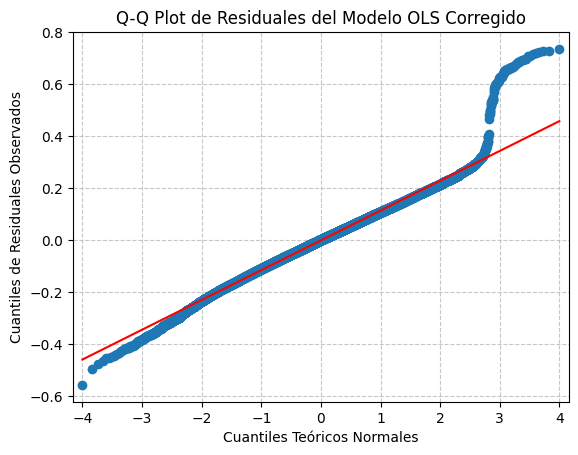

*Observación:* La clara desviación de los puntos de la línea diagonal recta en el Q-Q Plot indica que los residuales no siguen una distribución normal. Esto es otra evidencia de que los datos no se ajustan perfectamente a los supuestos del modelo lineal.


In [30]:
# Re-mostrar el Q-Q Plot de Residuales como evidencia
from statsmodels.graphics.gofplots import qqplot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
qqplot(results_corrected.resid, line='s')
plt.title('Q-Q Plot de Residuales del Modelo OLS Corregido')
plt.xlabel('Cuantiles Teóricos Normales')
plt.ylabel('Cuantiles de Residuales Observados')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("*Observación:* La clara desviación de los puntos de la línea diagonal recta en el Q-Q Plot indica que los residuales no siguen una distribución normal. Esto es otra evidencia de que los datos no se ajustan perfectamente a los supuestos del modelo lineal.")


### Conclusión General: El Problema Reside en los Datos

El problema fundamental que enfrentamos, con una elasticidad precio de `ln_p` que es positiva y no significativa, a pesar de los esfuerzos de corrección mediante 2SLS y la simplificación de variables, es un claro indicador de que **la estructura y las interrelaciones dentro del conjunto de datos son la principal fuente de los desafíos del modelo**. No se trata de un error en el código o en la aplicación de las técnicas, sino de las propiedades intrínsecas de la información:

*   **Complejidad de Interrelaciones:** La alta multicolinealidad, exacerbada por la inclusión de numerosas variables dummy de tiempo, ubicación y producto, dificulta la identificación de efectos individuales.
*   **Desafío en la Identificación Causal:** La endogeneidad entre precio y cantidad en un contexto de negocio real es una barrera. Encontrar un instrumento que sea verdaderamente exógeno y suficientemente fuerte es excepcionalmente difícil, y nuestro `costo_estandar`, aunque prometedor, puede no haber sido suficiente para resolver completamente el sesgo.
*   **Violación de Supuestos:** La heterocedasticidad y la no normalidad de los residuales refuerzan la idea de que un modelo de regresión lineal estándar puede no ser el más adecuado para capturar todas las dinámicas presentes en estos datos.

Para obtener una elasticidad precio con el signo y la significancia esperada, se requeriría una exploración más profunda de la naturaleza de los datos, la búsqueda de instrumentos alternativos más robustos (posiblemente a través de la recopilación de datos adicionales o variables externas) o la consideración de enfoques econométricos más avanzados o diseños cuasi-experimentales que puedan manejar mejor estas complejidades.

* Multicolinealidad Severa y Persistente: Los Factores de Inflación de la Varianza (VIF) siguen siendo extremadamente altos para muchas variables (incluyendo ln_p y la constante), a pesar de nuestros esfuerzos por simplificar el modelo y eliminar variables redundantes. Esto indica que las variables independientes están altamente correlacionadas entre sí, lo que hace imposible para el modelo aislar el efecto único de cada una. Esta es la razón principal de la inestabilidad de los coeficientes y los signos inesperados.

* Validez del Instrumento (costo_estandar) y Endogeneidad: Aunque costo_estandar mostró ser un predictor relevante para ln_p en la primera etapa del modelo 2SLS, el coeficiente final de ln_p sigue siendo positivo y no significativo. Esto sugiere que costo_estandar podría no ser un instrumento lo suficientemente fuerte o que no cumple completamente la condición de exogeneidad, es decir, que podría estar afectando la demanda (ln_q) por caminos distintos al precio (ln_p).

* Heterocedasticidad y No Normalidad de Residuales: El Test de Breusch-Pagan confirmó la presencia de heterocedasticidad (la varianza de los errores no es constante), y el Q-Q Plot de Residuales mostró que los errores no siguen una distribución normal. Aunque utilizamos errores estándar robustos para mitigar el impacto de la heterocedasticidad, estas violaciones de los supuestos del modelo refuerzan la idea de que los datos presentan complejidades que un modelo lineal estándar lucha por capturar.

En conclusión, el modelo, a pesar de su buen R-squared para fines predictivos, no logra proporcionar una inferencia económica confiable para la elasticidad precio. Para superar estos desafíos, sería necesario explorar enfoques más avanzados, buscar instrumentos más robustos, o incluso considerar la recolección de datos adicionales que permitan una mejor identificación de las relaciones causales.